In [1]:
import pandas as pd
import numpy as np
import plotly_express as px
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [2]:
df=pd.read_excel(r"C:\Users\ARUN\Downloads\Project2\dataset.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16146 entries, 0 to 16145
Data columns (total 80 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Dist Code                                    16146 non-null  int64  
 1   Year                                         16146 non-null  int64  
 2   State Code                                   16146 non-null  int64  
 3   State Name                                   16146 non-null  object 
 4   Dist Name                                    16146 non-null  object 
 5   RICE AREA (1000 ha)                          16146 non-null  float64
 6   RICE PRODUCTION (1000 tons)                  16146 non-null  float64
 7   RICE YIELD (Kg per ha)                       16146 non-null  float64
 8   WHEAT AREA (1000 ha)                         16146 non-null  float64
 9   WHEAT PRODUCTION (1000 tons)                 16146 non-null  float64
 10

In [4]:
df.shape

(16146, 80)

In [5]:
df.describe()

,Dist Code,Year,State Code,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),WHEAT YIELD (Kg per ha),KHARIF SORGHUM AREA (1000 ha),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
count,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,...,16146.00000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000
mean,269.769231,1991.496841,9.568562,128.593192,224.889565,1486.924784,77.057946,182.012746,1492.419859,22.632268,...,4500.15306,28.018367,7.229225,124.644823,7.750478,11.086250,18.677877,3.177038,1.194604,21.550328
std,278.309125,15.011185,4.988538,160.078825,326.629828,956.185281,100.394479,348.834254,1081.255367,45.062714,...,3153.97042,74.239648,25.042132,207.681147,13.591135,18.003257,25.881842,8.029509,4.285067,60.062601
min,1.000000,1966.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,78.000000,1978.000000,6.000000,10.400000,9.460000,800.000000,1.770000,2.000000,750.000000,0.000000,...,2000.00000,0.000000,0.000000,0.000000,0.310000,1.600000,2.520000,0.000000,0.060000,0.000000
50%,156.000000,1991.000000,10.000000,66.800000,95.840000,1333.210000,36.800000,42.700000,1347.450000,2.050000,...,4502.21000,0.050000,0.000000,0.000000,2.220000,4.740000,8.945000,0.390000,0.280000,1.200000
75%,241.000000,2005.000000,12.000000,191.390000,315.715000,2113.517500,123.000000,215.192500,2131.580000,20.900000,...,6704.60500,10.097500,2.000000,202.270000,8.790000,12.510000,23.570000,3.150000,0.880000,16.762500
max,917.000000,2017.000000,20.000000,1154.230000,3215.010000,5653.830000,879.490000,4305.500000,5541.520000,334.800000,...,22062.30000,800.890000,376.610000,5000.000000,159.540000,200.060000,240.990000,111.610000,131.350000,1162.660000


In [6]:
df.columns

Index(['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name',
       'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)',
       'RICE YIELD (Kg per ha)', 'WHEAT AREA (1000 ha)',
       'WHEAT PRODUCTION (1000 tons)', 'WHEAT YIELD (Kg per ha)',
       'KHARIF SORGHUM AREA (1000 ha)',
       'KHARIF SORGHUM PRODUCTION (1000 tons)',
       'KHARIF SORGHUM YIELD (Kg per ha)', 'RABI SORGHUM AREA (1000 ha)',
       'RABI SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM YIELD (Kg per ha)',
       'SORGHUM AREA (1000 ha)', 'SORGHUM PRODUCTION (1000 tons)',
       'SORGHUM YIELD (Kg per ha)', 'PEARL MILLET AREA (1000 ha)',
       'PEARL MILLET PRODUCTION (1000 tons)', 'PEARL MILLET YIELD (Kg per ha)',
       'MAIZE AREA (1000 ha)', 'MAIZE PRODUCTION (1000 tons)',
       'MAIZE YIELD (Kg per ha)', 'FINGER MILLET AREA (1000 ha)',
       'FINGER MILLET PRODUCTION (1000 tons)',
       'FINGER MILLET YIELD (Kg per ha)', 'BARLEY AREA (1000 ha)',
       'BARLEY PRODUCTION (1000 tons)', 'BARLEY 

In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

date_column = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
numeric_column = df.select_dtypes(include=['number']).columns.tolist()
text_column = df.select_dtypes(include=['object']).columns.tolist()

In [8]:
#handling null values
print(date_column)
for year in date_column:
    if df[year].isnull:
        print(f"{df[year]} contains {df[year].isnull().sum()} null values")
        df[year]=df[year].fillna(0)
for value in numeric_column:
    if df[value].isnull:
        print(f"{value} contains {df[value].isnull().sum()} null values")
        df[value]=df[value].fillna(0)
for text in text_column:
    if df[text].isnull:
        print(f" {text} contains {df[text].isnull().sum()} null values")
        df[text]=df[text].fillna("NA")

#changing data type
int_column=['dist_code','state_code','year']
for col in int_column:
    df[col]=df[col].astype(int)

fill_column=[col for col in numeric_column if col not in int_column]
for col in fill_column:
    df[col]=df[col].astype(float)









[]
dist_code contains 0 null values
year contains 0 null values
state_code contains 0 null values
rice_area_(1000_ha) contains 0 null values
rice_production_(1000_tons) contains 0 null values
rice_yield_(kg_per_ha) contains 0 null values
wheat_area_(1000_ha) contains 0 null values
wheat_production_(1000_tons) contains 0 null values
wheat_yield_(kg_per_ha) contains 0 null values
kharif_sorghum_area_(1000_ha) contains 0 null values
kharif_sorghum_production_(1000_tons) contains 0 null values
kharif_sorghum_yield_(kg_per_ha) contains 0 null values
rabi_sorghum_area_(1000_ha) contains 0 null values
rabi_sorghum_production_(1000_tons) contains 0 null values
rabi_sorghum_yield_(kg_per_ha) contains 0 null values
sorghum_area_(1000_ha) contains 0 null values
sorghum_production_(1000_tons) contains 0 null values
sorghum_yield_(kg_per_ha) contains 0 null values
pearl_millet_area_(1000_ha) contains 0 null values
pearl_millet_production_(1000_tons) contains 0 null values
pearl_millet_yield_(kg_per

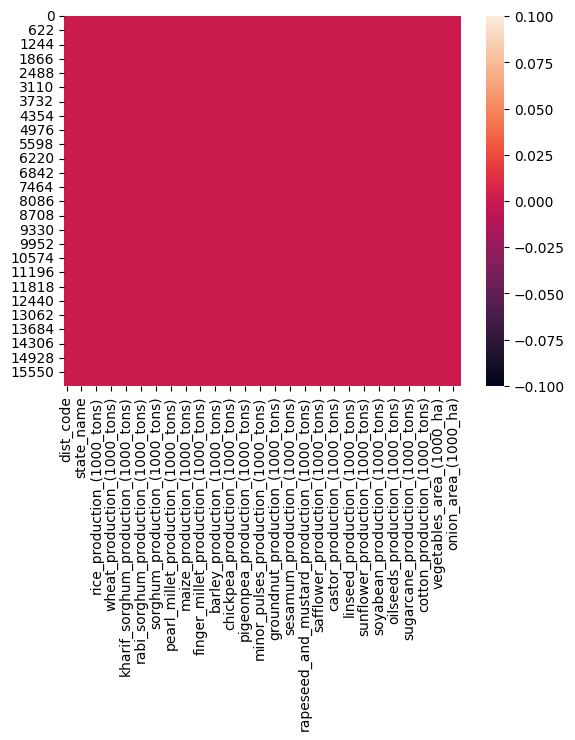

In [9]:
plt.figure()
sns.heatmap(df.isnull())
plt.show()

In [10]:
df[df.duplicated()]
print(f"data has {df.duplicated().sum()} duplicate values")

data has 0 duplicate values


In [11]:
#text handling
print(text_column)
df['state_name']=df['state_name'].str.title().str.strip()
df['dist_name']=df['dist_name'].str.title().str.strip()

['state_name', 'dist_name']


In [12]:
#numeric value handling
for value in numeric_column:
    df.loc[df[value] < 0, value] = 0

    

In [13]:
#date value handling
df['year'].min()
df["year"].max()
df[(df["year"]<df['year'].min()) | (df['year']>df["year"].max())]

,dist_code,year,state_code,state_name,dist_name,rice_area_(1000_ha),rice_production_(1000_tons),rice_yield_(kg_per_ha),wheat_area_(1000_ha),wheat_production_(1000_tons),...,sugarcane_yield_(kg_per_ha),cotton_area_(1000_ha),cotton_production_(1000_tons),cotton_yield_(kg_per_ha),fruits_area_(1000_ha),vegetables_area_(1000_ha),fruits_and_vegetables_area_(1000_ha),potatoes_area_(1000_ha),onion_area_(1000_ha),fodder_area_(1000_ha)


In [14]:
df['state_code'].unique()

df["state_name"]=df["state_name"].str.replace('Orissa','Odisa')
df['state_name'].unique()
df["dist_name"].unique()
for col in text_column:
    print(df[col].value_counts())

state_name
Uttar Pradesh       2392
Madhya Pradesh      1924
Rajasthan           1352
Maharashtra         1348
Karnataka            988
Gujarat              936
West Bengal          774
Odisa                676
Tamil Nadu           624
Bihar                572
Andhra Pradesh       572
Punjab               572
Himachal Pradesh     520
Assam                520
Kerala               516
Telangana            468
Uttarakhand          416
Haryana              364
Chhattisgarh         312
Jharkhand            300
Name: count, dtype: int64
dist_name
Gaya             52
Durg             52
Malda            52
Darjeeling       52
Jalpaiguri       52
                 ..
Dhanbad          50
Singhbhum        50
Bombay           48
Malappuram       48
West Dinajpur    46
Name: count, Length: 311, dtype: int64


In [15]:
#store cleaned excel file in csv format
df.to_csv("cleaned_dataset.csv", index=False)
print("Cleaning Summary")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Cleaning Summary
Rows: 16146
Columns: 80


In [16]:
cleaned_df=pd.read_csv("cleaned_dataset.csv")
cleaned_df

,dist_code,year,state_code,state_name,dist_name,rice_area_(1000_ha),rice_production_(1000_tons),rice_yield_(kg_per_ha),wheat_area_(1000_ha),wheat_production_(1000_tons),...,sugarcane_yield_(kg_per_ha),cotton_area_(1000_ha),cotton_production_(1000_tons),cotton_yield_(kg_per_ha),fruits_area_(1000_ha),vegetables_area_(1000_ha),fruits_and_vegetables_area_(1000_ha),potatoes_area_(1000_ha),onion_area_(1000_ha),fodder_area_(1000_ha)
0,1,1966,14,Chhattisgarh,Durg,548.00,185.00,337.59,44.00,20.00,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.00,409.00,747.71,50.00,26.00,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.30,468.00,841.27,53.70,30.00,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.40,400.80,711.40,49.40,26.50,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.60,473.60,828.55,44.20,29.00,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16141,917,2013,15,Jharkhand,Singhbhum,267.06,579.70,2170.67,1.53,1.85,...,0.00,0.0,0.0,0.0,0.00,9.02,9.03,0.48,0.08,0.00
16142,917,2014,15,Jharkhand,Singhbhum,256.33,586.63,2288.57,5.36,6.65,...,0.00,0.0,0.0,0.0,0.00,8.63,8.64,0.46,0.04,0.00
16143,917,2015,15,Jharkhand,Singhbhum,263.21,264.71,1005.70,1.99,1.82,...,0.00,0.0,0.0,0.0,0.00,6.84,6.85,0.42,0.01,0.00
16144,917,2016,15,Jharkhand,Singhbhum,224.05,319.01,1423.84,0.38,0.83,...,0.00,0.0,0.0,0.0,0.03,6.40,6.43,0.03,0.01,0.00


In [17]:
#export dataset to sql
!pip install sqlalchemy

In [18]:
#upload dataset to database
import sqlalchemy 
from sqlalchemy import create_engine, text
engine = create_engine( "mssql+pyodbc://Agamagizhan/agriculture" "?driver=ODBC+Driver+17+for+SQL+Server" "&trusted_connection=yes" )
cleaned_df.to_sql("cleaned_dataset.csv", engine, if_exists="replace", index=False)
print("✅ Uploaded!", len(cleaned_df), "rows")

✅ Uploaded! 16146 rows


EDA

In [19]:
cleaned_df

,dist_code,year,state_code,state_name,dist_name,rice_area_(1000_ha),rice_production_(1000_tons),rice_yield_(kg_per_ha),wheat_area_(1000_ha),wheat_production_(1000_tons),...,sugarcane_yield_(kg_per_ha),cotton_area_(1000_ha),cotton_production_(1000_tons),cotton_yield_(kg_per_ha),fruits_area_(1000_ha),vegetables_area_(1000_ha),fruits_and_vegetables_area_(1000_ha),potatoes_area_(1000_ha),onion_area_(1000_ha),fodder_area_(1000_ha)
0,1,1966,14,Chhattisgarh,Durg,548.00,185.00,337.59,44.00,20.00,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.00,409.00,747.71,50.00,26.00,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.30,468.00,841.27,53.70,30.00,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.40,400.80,711.40,49.40,26.50,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.60,473.60,828.55,44.20,29.00,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16141,917,2013,15,Jharkhand,Singhbhum,267.06,579.70,2170.67,1.53,1.85,...,0.00,0.0,0.0,0.0,0.00,9.02,9.03,0.48,0.08,0.00
16142,917,2014,15,Jharkhand,Singhbhum,256.33,586.63,2288.57,5.36,6.65,...,0.00,0.0,0.0,0.0,0.00,8.63,8.64,0.46,0.04,0.00
16143,917,2015,15,Jharkhand,Singhbhum,263.21,264.71,1005.70,1.99,1.82,...,0.00,0.0,0.0,0.0,0.00,6.84,6.85,0.42,0.01,0.00
16144,917,2016,15,Jharkhand,Singhbhum,224.05,319.01,1423.84,0.38,0.83,...,0.00,0.0,0.0,0.0,0.03,6.40,6.43,0.03,0.01,0.00


In [20]:
cleaned_df.select_dtypes(include=np.number).corr()

,dist_code,year,state_code,rice_area_(1000_ha),rice_production_(1000_tons),rice_yield_(kg_per_ha),wheat_area_(1000_ha),wheat_production_(1000_tons),wheat_yield_(kg_per_ha),kharif_sorghum_area_(1000_ha),...,sugarcane_yield_(kg_per_ha),cotton_area_(1000_ha),cotton_production_(1000_tons),cotton_yield_(kg_per_ha),fruits_area_(1000_ha),vegetables_area_(1000_ha),fruits_and_vegetables_area_(1000_ha),potatoes_area_(1000_ha),onion_area_(1000_ha),fodder_area_(1000_ha)
dist_code,1.000000,0.000284,0.324730,0.378682,0.230704,-0.007321,-0.109554,-0.090325,0.018906,-0.302371,...,-0.179345,-0.213176,-0.150437,-0.184771,0.105509,0.403753,0.327323,0.269188,-0.055460,-0.168411
year,0.000284,1.000000,0.000714,0.046177,0.232395,0.388248,0.142018,0.242388,0.375422,-0.224126,...,0.099544,0.052632,0.159235,0.160649,0.174321,0.179194,0.206936,0.145749,0.102725,-0.010391
state_code,0.324730,0.000714,1.000000,0.063496,0.035630,0.058227,-0.134052,-0.090972,-0.112841,-0.169526,...,-0.285218,-0.210767,-0.164389,-0.182089,-0.034533,0.051368,0.018433,0.090585,-0.122576,-0.107610
rice_area_(1000_ha),0.378682,0.046177,0.063496,1.000000,0.832514,0.220054,0.013316,0.066991,-0.012576,-0.268428,...,0.129984,-0.154500,-0.068263,-0.014134,0.184088,0.413932,0.377262,0.264592,-0.015115,-0.168618
rice_production_(1000_tons),0.230704,0.232395,0.035630,0.832514,1.000000,0.529760,0.138418,0.265868,0.107560,-0.233074,...,0.262384,-0.066403,0.043976,0.131044,0.264088,0.398544,0.409016,0.291352,-0.018863,-0.098264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vegetables_area_(1000_ha),0.403753,0.179194,0.051368,0.413932,0.398544,0.185218,-0.054233,-0.019423,0.076376,-0.152312,...,0.179872,-0.094910,-0.048254,0.022948,0.335453,1.000000,0.858243,0.471619,0.248005,-0.086192
fruits_and_vegetables_area_(1000_ha),0.327323,0.206936,0.018433,0.377262,0.409016,0.294078,-0.129379,-0.068292,-0.093867,-0.147979,...,0.231648,-0.060874,-0.017015,0.091633,0.758544,0.858243,1.000000,0.317774,0.213286,-0.097282
potatoes_area_(1000_ha),0.269188,0.145749,0.090585,0.264592,0.291352,0.146632,0.146373,0.133548,0.235019,-0.154953,...,0.060710,-0.121392,-0.082068,-0.099742,-0.018366,0.471619,0.317774,1.000000,-0.003146,-0.063297
onion_area_(1000_ha),-0.055460,0.102725,-0.122576,-0.015115,-0.018863,0.014045,-0.049069,-0.052938,-0.016844,0.046046,...,0.175073,0.116082,0.121933,0.133975,0.081410,0.248005,0.213286,-0.003146,1.000000,0.006389


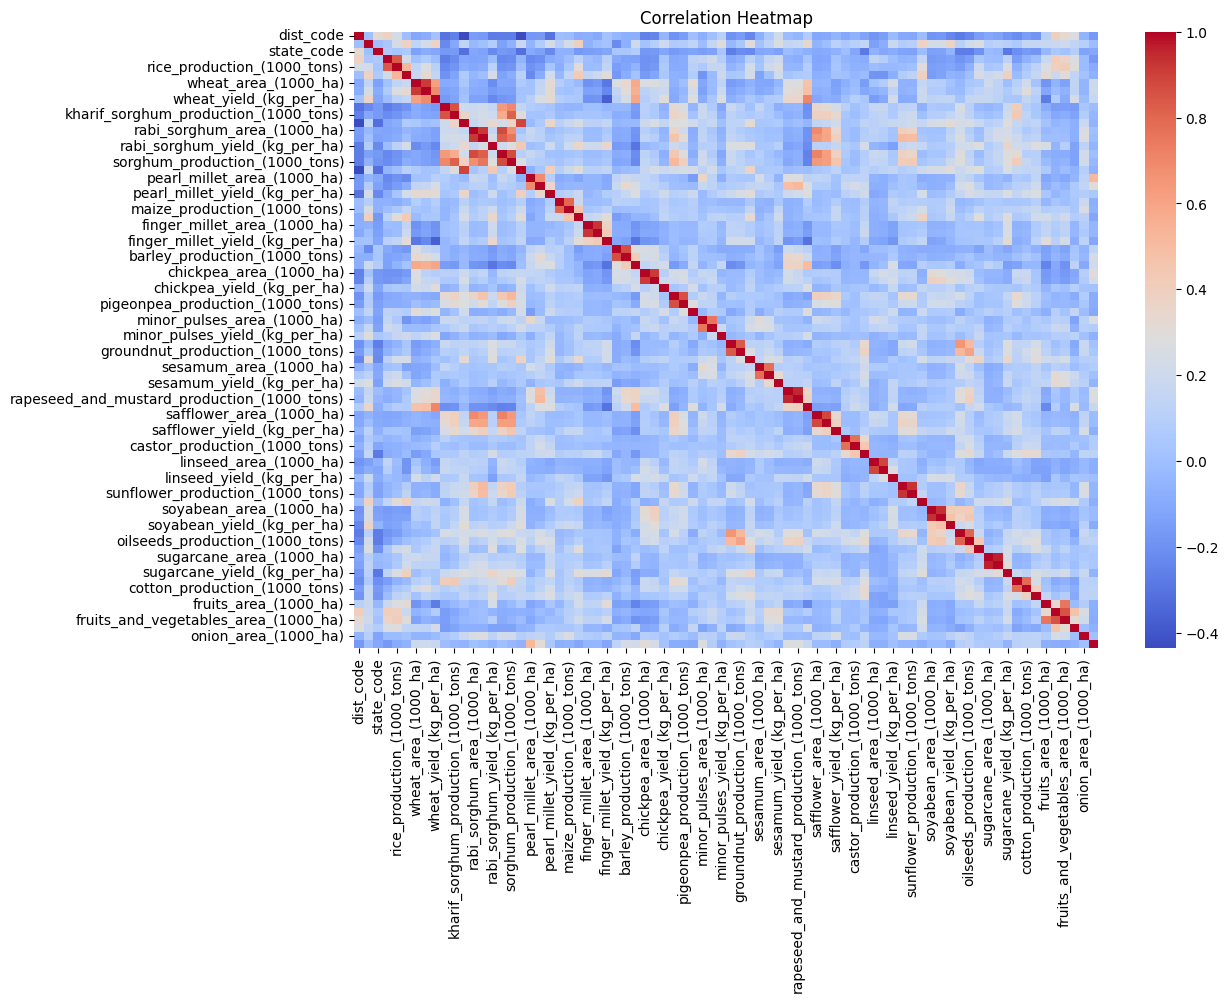

In [21]:
corr_matrix = cleaned_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Insight:
Crop production is strongly influenced by cultivation area and moderately by yield, while most crops show weak correlation with each other, indicating independent agricultural patterns.

In [22]:
for col in text_column:
    print(cleaned_df[col].value_counts())


state_name
Uttar Pradesh       2392
Madhya Pradesh      1924
Rajasthan           1352
Maharashtra         1348
Karnataka            988
Gujarat              936
West Bengal          774
Odisa                676
Tamil Nadu           624
Bihar                572
Andhra Pradesh       572
Punjab               572
Himachal Pradesh     520
Assam                520
Kerala               516
Telangana            468
Uttarakhand          416
Haryana              364
Chhattisgarh         312
Jharkhand            300
Name: count, dtype: int64
dist_name
Gaya             52
Durg             52
Malda            52
Darjeeling       52
Jalpaiguri       52
                 ..
Dhanbad          50
Singhbhum        50
Bombay           48
Malappuram       48
West Dinajpur    46
Name: count, Length: 311, dtype: int64


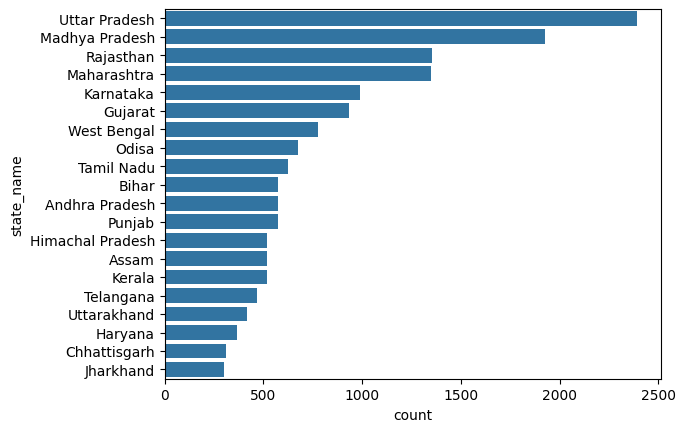

In [23]:
plt.figure()
sns.countplot(y=cleaned_df['state_name'],
              order=cleaned_df['state_name'].value_counts().index)
plt.show()


The dataset is dominated by Uttar Pradesh and Madhya Pradesh, indicating higher agricultural activity or data availability in these states.
Lower representation from Jharkhand and Chhattisgarh suggests limited agricultural records in the dataset.

In [24]:
cleaned_df.columns

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_(1000_ha)', 'rice_production_(1000_tons)',
       'rice_yield_(kg_per_ha)', 'wheat_area_(1000_ha)',
       'wheat_production_(1000_tons)', 'wheat_yield_(kg_per_ha)',
       'kharif_sorghum_area_(1000_ha)',
       'kharif_sorghum_production_(1000_tons)',
       'kharif_sorghum_yield_(kg_per_ha)', 'rabi_sorghum_area_(1000_ha)',
       'rabi_sorghum_production_(1000_tons)', 'rabi_sorghum_yield_(kg_per_ha)',
       'sorghum_area_(1000_ha)', 'sorghum_production_(1000_tons)',
       'sorghum_yield_(kg_per_ha)', 'pearl_millet_area_(1000_ha)',
       'pearl_millet_production_(1000_tons)', 'pearl_millet_yield_(kg_per_ha)',
       'maize_area_(1000_ha)', 'maize_production_(1000_tons)',
       'maize_yield_(kg_per_ha)', 'finger_millet_area_(1000_ha)',
       'finger_millet_production_(1000_tons)',
       'finger_millet_yield_(kg_per_ha)', 'barley_area_(1000_ha)',
       'barley_production_(1000_tons)', 'barley_

In [25]:
!pip install --upgrade nbformat

In [26]:

top_7_rice_production_state = cleaned_df.groupby('state_name')['rice_production_(1000_tons)'] \
    .sum().sort_values(ascending=False).head(7).reset_index()

print(top_7_rice_production_state)

       state_name  rice_production_(1000_tons)
0     West Bengal                    544232.26
1   Uttar Pradesh                    445597.62
2          Punjab                    335040.10
3  Andhra Pradesh                    315185.40
4      Tamil Nadu                    291201.51
5           Odisa                    282532.93
6           Bihar                    231759.00


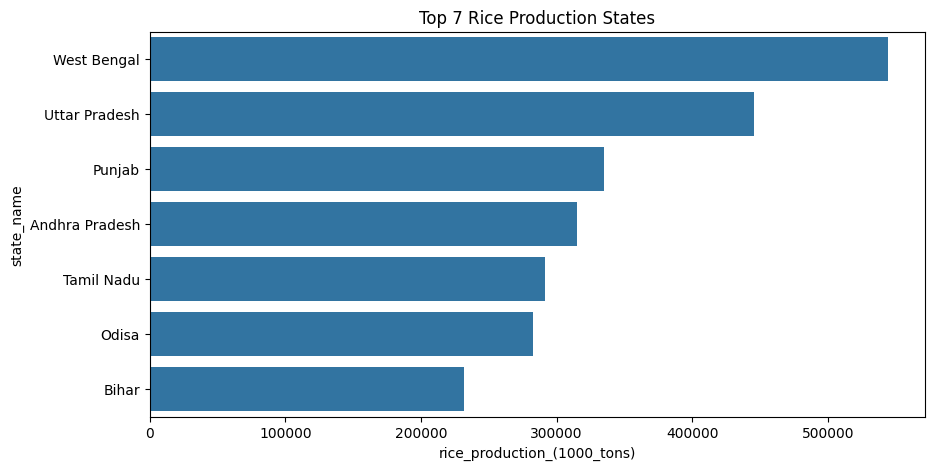

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_7_rice_production_state,
    x='rice_production_(1000_tons)',
    y='state_name'
)

plt.title("Top 7 Rice Production States")
plt.show()

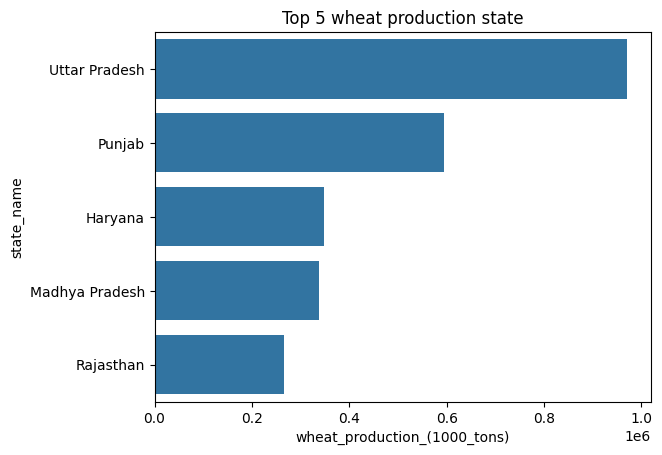

In [28]:
top_5_wheat_producing_states=cleaned_df.groupby('state_name')['wheat_production_(1000_tons)'].sum().sort_values(ascending=False).head(5).reset_index()
plt.figure()
sns.barplot(top_5_wheat_producing_states,x='wheat_production_(1000_tons)',y='state_name')
plt.title("Top 5 wheat production state")
plt.show()

In [29]:
#Top 5 Wheat Producing States Data(Bar_chart)and its percentage(%)
total_wheat_production=cleaned_df['wheat_production_(1000_tons)'].sum()
top_5_wheat_producing_states=cleaned_df.groupby('state_name')['wheat_production_(1000_tons)'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_wheat_producing_states["percentage"]=percentage=top_5_wheat_producing_states['wheat_production_(1000_tons)']/total_wheat_production
print(top_5_wheat_producing_states)

       state_name  wheat_production_(1000_tons)  percentage
0   Uttar Pradesh                     970210.07    0.330137
1          Punjab                     593848.90    0.202071
2         Haryana                     348429.60    0.118561
3  Madhya Pradesh                     338644.25    0.115232
4       Rajasthan                     265994.99    0.090511


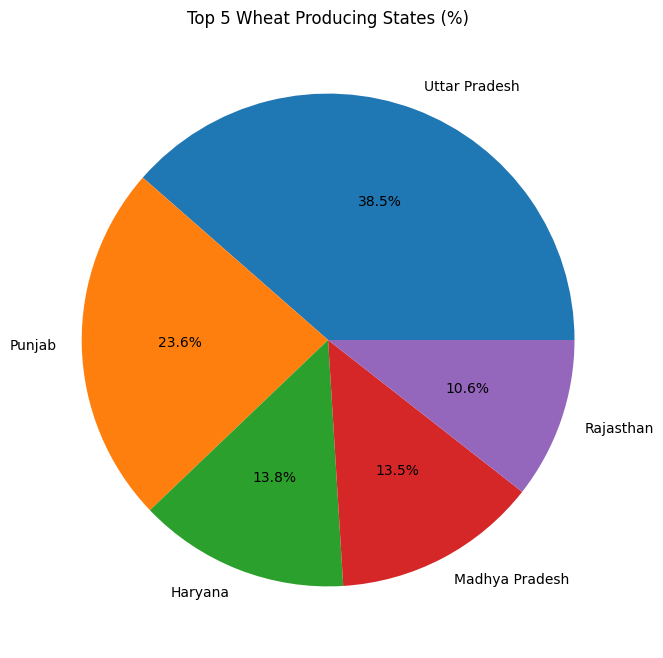

In [30]:
plt.figure(figsize=(8,8))

plt.pie(
    top_5_wheat_producing_states['wheat_production_(1000_tons)'],
    labels=top_5_wheat_producing_states['state_name'],
    autopct='%1.1f%%'
)

plt.title("Top 5 Wheat Producing States (%)")
plt.show()

In [31]:
#Oil seed production by top 5 states
cleaned_df.columns

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_(1000_ha)', 'rice_production_(1000_tons)',
       'rice_yield_(kg_per_ha)', 'wheat_area_(1000_ha)',
       'wheat_production_(1000_tons)', 'wheat_yield_(kg_per_ha)',
       'kharif_sorghum_area_(1000_ha)',
       'kharif_sorghum_production_(1000_tons)',
       'kharif_sorghum_yield_(kg_per_ha)', 'rabi_sorghum_area_(1000_ha)',
       'rabi_sorghum_production_(1000_tons)', 'rabi_sorghum_yield_(kg_per_ha)',
       'sorghum_area_(1000_ha)', 'sorghum_production_(1000_tons)',
       'sorghum_yield_(kg_per_ha)', 'pearl_millet_area_(1000_ha)',
       'pearl_millet_production_(1000_tons)', 'pearl_millet_yield_(kg_per_ha)',
       'maize_area_(1000_ha)', 'maize_production_(1000_tons)',
       'maize_yield_(kg_per_ha)', 'finger_millet_area_(1000_ha)',
       'finger_millet_production_(1000_tons)',
       'finger_millet_yield_(kg_per_ha)', 'barley_area_(1000_ha)',
       'barley_production_(1000_tons)', 'barley_

In [32]:

top_5_oil_production_states=cleaned_df.groupby('state_name')['oilseeds_production_(1000_tons)'].sum().sort_values(ascending=False).reset_index().head(5)
print(top_5_oil_production_states)

       state_name  oilseeds_production_(1000_tons)
0  Madhya Pradesh                        153705.79
1         Gujarat                        126314.01
2       Rajasthan                        122726.86
3     Maharashtra                         95567.91
4  Andhra Pradesh                         76888.09


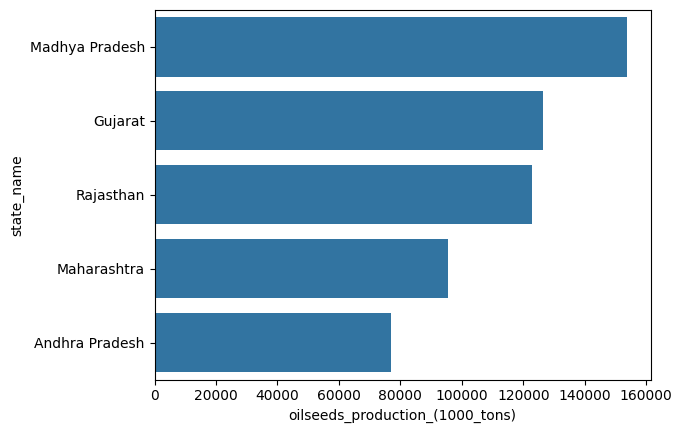

In [33]:
plt.figure()
sns.barplot(top_5_oil_production_states,x='oilseeds_production_(1000_tons)',y='state_name')
plt.show()

In [34]:
#Top 7 SUNFLOWER PRODUCTION State
cleaned_df.columns
top_7_sunflower_production_state=cleaned_df.groupby('state_name')['sunflower_production_(1000_tons)'].sum().sort_values(ascending=False).head(7).reset_index()
print(top_7_sunflower_production_state)

       state_name  sunflower_production_(1000_tons)
0       Karnataka                          10785.87
1     Maharashtra                           5599.46
2  Andhra Pradesh                           4447.78
3       Telangana                           1401.06
4          Punjab                           1081.86
5      Tamil Nadu                            762.38
6   Uttar Pradesh                            552.66


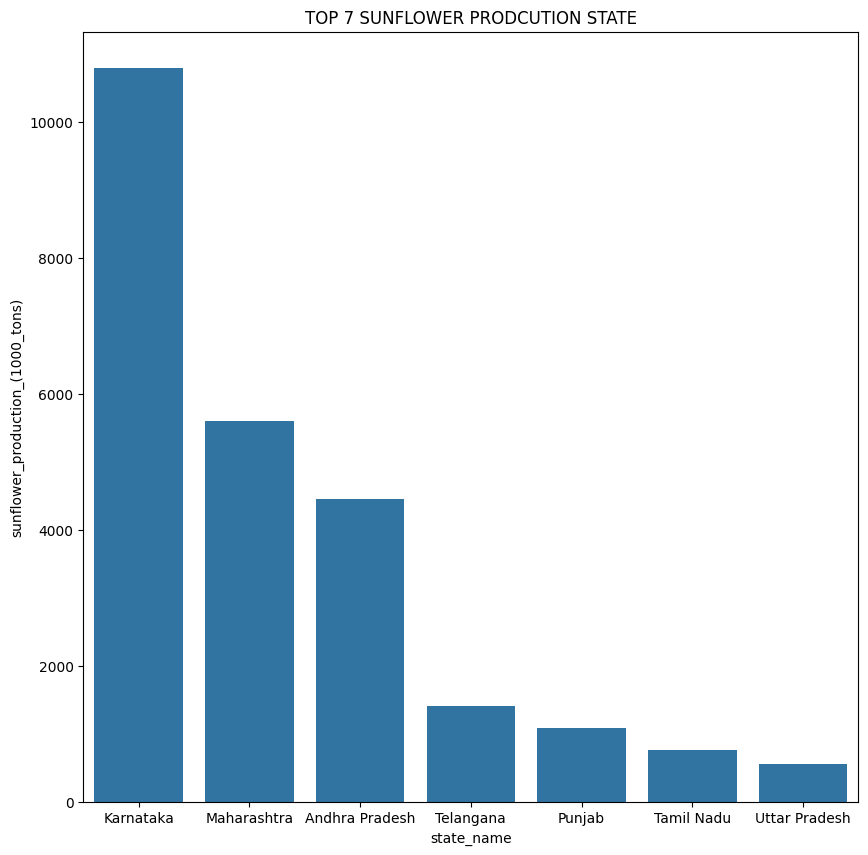

In [35]:
plt.figure(figsize=(10,10))
sns.barplot(top_7_sunflower_production_state,x='state_name',y='sunflower_production_(1000_tons)')
plt.title("TOP 7 SUNFLOWER PRODCUTION STATE")
plt.show()

In [36]:
sugarcane_yearly = cleaned_df.groupby('year')['sugarcane_production_(1000_tons)'] \
    .sum().reset_index()
print(sugarcane_yearly)

    year  sugarcane_production_(1000_tons)
0   1966                           9371.71
1   1967                           9584.38
2   1968                          12730.70
3   1969                          13739.57
4   1970                          12391.60
5   1971                          11674.01
6   1972                          12583.28
7   1973                          14402.62
8   1974                          14650.45
9   1975                          14931.26
10  1976                          15490.12
11  1977                          18146.92
12  1978                          15620.47
13  1979                          12699.56
14  1980                          15164.07
15  1981                          18027.94
16  1982                          18627.78
17  1983                          17354.32
18  1984                          17019.60
19  1985                          16853.80
20  1986                          17962.70
21  1987                          19272.10
22  1988   

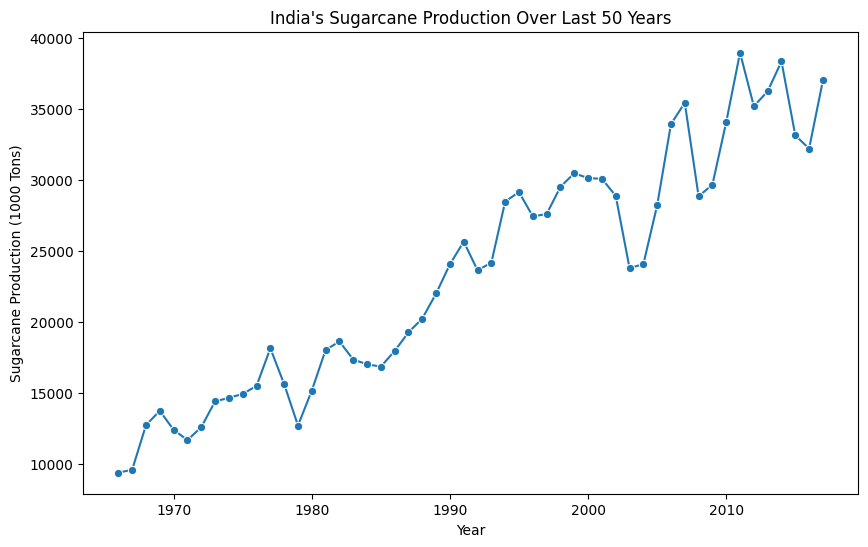

In [37]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=sugarcane_yearly,
    x='year',
    y='sugarcane_production_(1000_tons)',
    marker='o'
)

plt.title("India's Sugarcane Production Over Last 50 Years")
plt.xlabel("Year")
plt.ylabel("Sugarcane Production (1000 Tons)")

plt.show()

Sugarcane production in India shows an increasing trend over the last 50 years, indicating growth in agricultural output and improved farming practices.

In [38]:
#Rice Production Vs Wheat Production (Last 50y)
rice_wheat_yearly = cleaned_df.groupby('year')[[
    'rice_production_(1000_tons)',
    'wheat_production_(1000_tons)'
]].sum().reset_index()

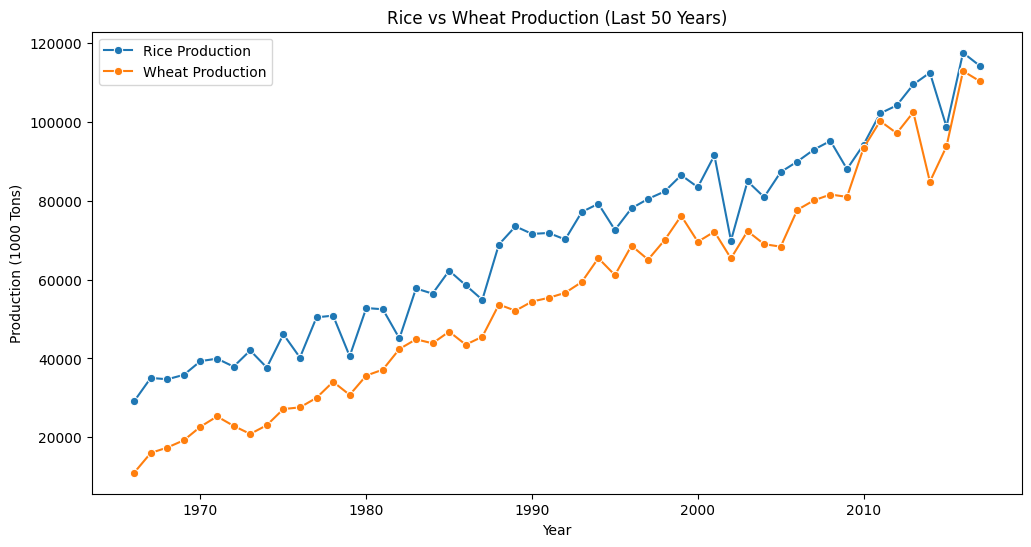

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=rice_wheat_yearly,
    x='year',
    y='rice_production_(1000_tons)',
    label='Rice Production',
    marker='o'
)

sns.lineplot(
    data=rice_wheat_yearly,
    x='year',
    y='wheat_production_(1000_tons)',
    label='Wheat Production',
    marker='o'
)

plt.title("Rice vs Wheat Production (Last 50 Years)")
plt.xlabel("Year")
plt.ylabel("Production (1000 Tons)")
plt.legend()

plt.show()

Rice production is consistently higher than wheat production over the last 50 years, and both crops show a steady growth trend in India.

In [40]:
cleaned_df['state_name'].unique()

array(['Chhattisgarh', 'Madhya Pradesh', 'Andhra Pradesh', 'Telangana',
       'Karnataka', 'Tamil Nadu', 'Maharashtra', 'Gujarat', 'Rajasthan',
       'Punjab', 'Haryana', 'Uttar Pradesh', 'Uttarakhand', 'Assam',
       'Himachal Pradesh', 'Kerala', 'Odisa', 'West Bengal', 'Bihar',
       'Jharkhand'], dtype=object)

In [41]:
#Rice Production By West Bengal Districts
cleaned_df.columns
rice_production_by_west_bangal_disctricts=cleaned_df[cleaned_df['state_name']=='West Bengal'].groupby('dist_name')['rice_production_(1000_tons)'].sum().sort_values(ascending=False).reset_index()
print(rice_production_by_west_bangal_disctricts)

        dist_name  rice_production_(1000_tons)
0        Midnapur                     98868.28
1         Burdwan                     71422.15
2     24 Parganas                     63011.99
3         Birbhum                     42213.81
4         Bankura                     40165.20
5     Murshidabad                     37261.24
6   West Dinajpur                     35224.87
7         Hooghly                     30962.21
8           Nadia                     28016.30
9         Purulia                     23147.50
10          Malda                     22497.83
11    Cooch Behar                     20949.15
12     Jalpaiguri                     17372.00
13         Howrah                     10264.53
14     Darjeeling                      2855.20


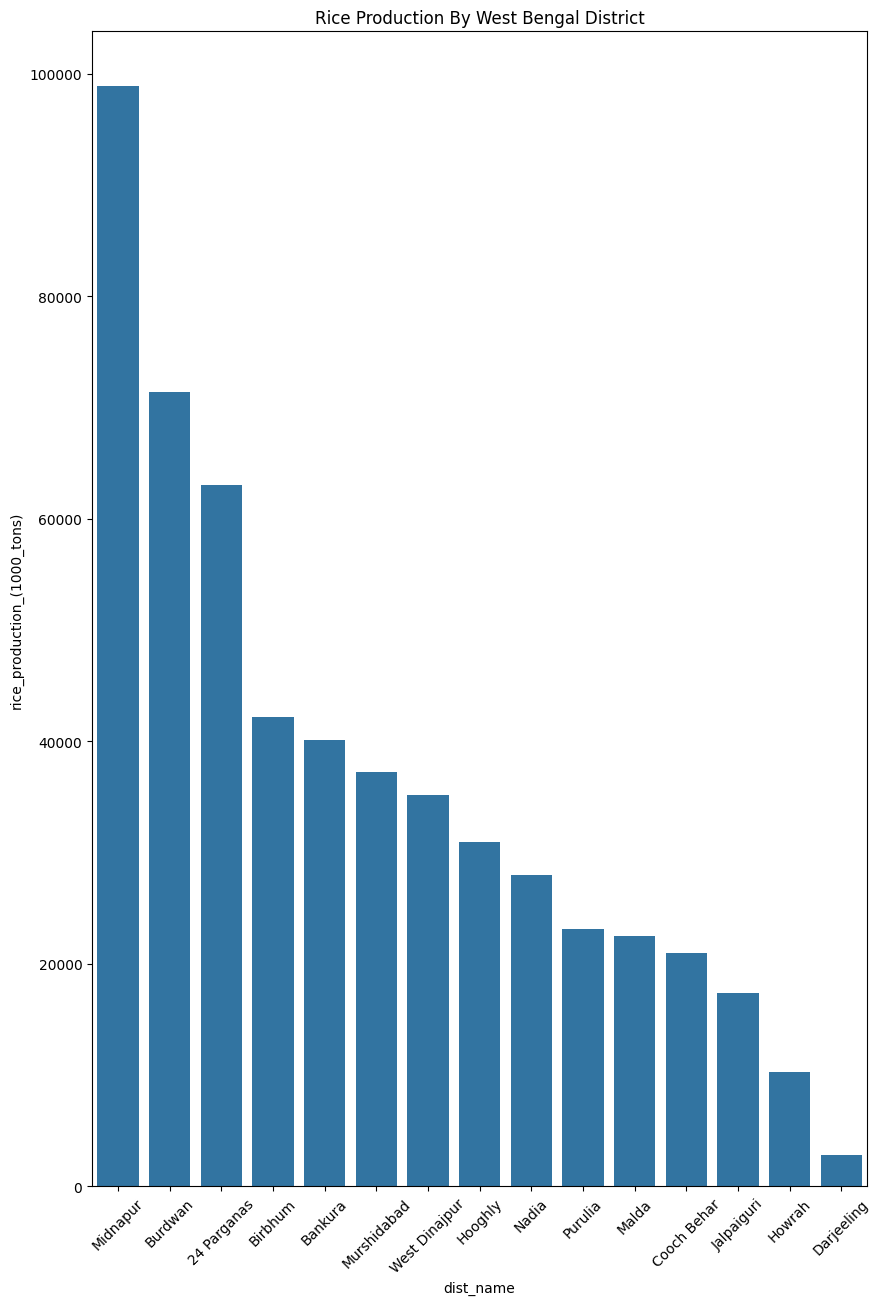

In [42]:
plt.figure(figsize=(10,15))
sns.barplot(rice_production_by_west_bangal_disctricts,x='dist_name',y='rice_production_(1000_tons)')
plt.xticks(rotation=45)
plt.title("Rice Production By West Bengal District")
plt.show()



In [43]:
#Top 10 Wheat Production Years From UP
top_10_wheat_production_year_from_up=cleaned_df[cleaned_df['state_name']=="Uttar Pradesh"].groupby('year')['wheat_production_(1000_tons)'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_10_wheat_production_year_from_up)

   year  wheat_production_(1000_tons)
0  2017                      35798.60
1  2016                      35120.90
2  2011                      32271.69
3  2013                      31611.63
4  2010                      30602.91
5  2008                      29110.93
6  2012                      29041.28
7  2009                      27910.80
8  2015                      27010.39
9  2003                      26445.45


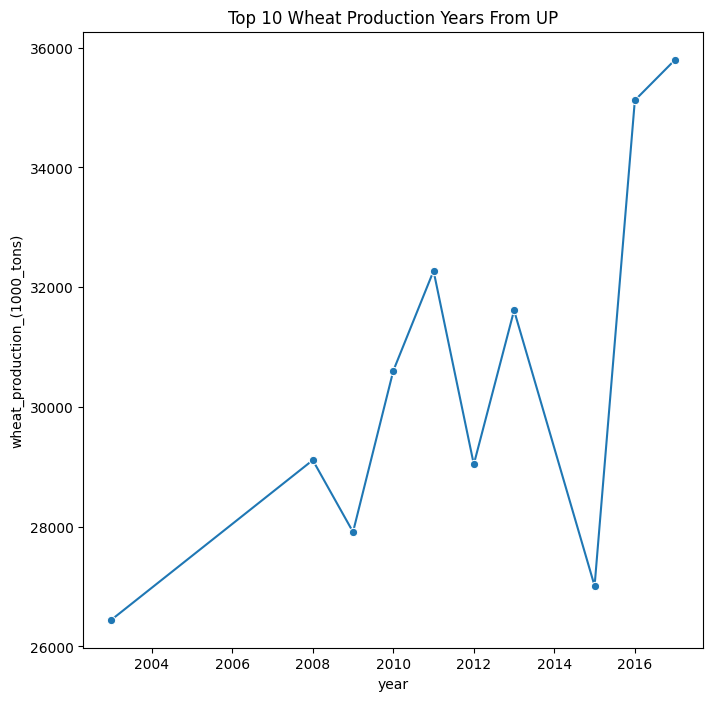

In [50]:
plt.figure(figsize=(8,8))
sns.lineplot(top_10_wheat_production_year_from_up,
             x='year',
             y="wheat_production_(1000_tons)",
             marker='o')
plt.title("Top 10 Wheat Production Years From UP")
plt.show()

In [45]:
millet_production = cleaned_df.groupby('year')[[
    'pearl_millet_production_(1000_tons)',
    'finger_millet_production_(1000_tons)'
]].sum().reset_index().sort_values(by='year')
print(millet_production)

    year  pearl_millet_production_(1000_tons)  \
0   1966                              4540.06   
1   1967                              5246.99   
2   1968                              3863.45   
3   1969                              5526.42   
4   1970                              8018.16   
5   1971                              5250.84   
6   1972                              3935.34   
7   1973                              7266.05   
8   1974                              3388.46   
9   1975                              5625.08   
10  1976                              5633.29   
11  1977                              4726.99   
12  1978                              5510.36   
13  1979                              4535.74   
14  1980                              5363.72   
15  1981                              5360.47   
16  1982                              5110.52   
17  1983                              7603.26   
18  1984                              6151.85   
19  1985            

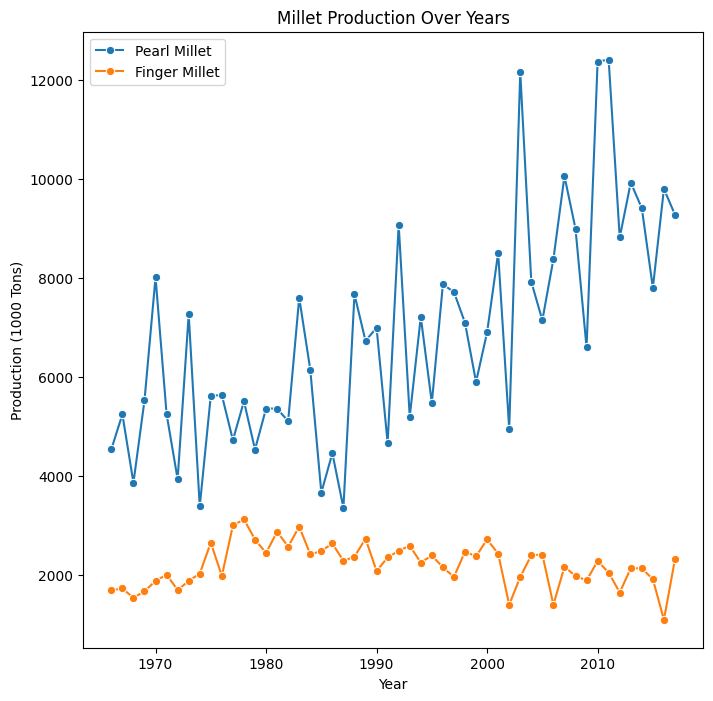

In [51]:
plt.figure(figsize=(8,8))

sns.lineplot(
    data=millet_production,
    x='year',
    y='pearl_millet_production_(1000_tons)',
    label='Pearl Millet',\
    marker='o'
)
sns.lineplot(
    data=millet_production,
    x='year',
    y='finger_millet_production_(1000_tons)',
    label='Finger Millet',
    marker='o'
)
plt.title("Millet Production Over Years")
plt.xlabel("Year")
plt.ylabel("Production (1000 Tons)")

plt.show()

Pearl millet production is generally higher than finger millet production over the years, showing stronger cultivation and demand for pearl millet.

In [57]:
region_map = {
    'Tamil Nadu': 'South',
    'Karnataka': 'South',
    'Kerala': 'South',
    'Andhra Pradesh': 'South',
    'Telangana': 'South',

    'Maharashtra': 'West',
    'Gujarat': 'West',
    'Rajasthan': 'West',

    'Uttar Pradesh': 'North',
    'Punjab': 'North',
    'Haryana': 'North',

    'Bihar': 'East',
    'West Bengal': 'East',
    'Odisha': 'East',

    'Madhya Pradesh': 'Central',
    'Chhattisgarh': 'Central'
}
cleaned_df['region']=cleaned_df['state_name'].map(region_map)

In [62]:
cleaned_df.columns

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_(1000_ha)', 'rice_production_(1000_tons)',
       'rice_yield_(kg_per_ha)', 'wheat_area_(1000_ha)',
       'wheat_production_(1000_tons)', 'wheat_yield_(kg_per_ha)',
       'kharif_sorghum_area_(1000_ha)',
       'kharif_sorghum_production_(1000_tons)',
       'kharif_sorghum_yield_(kg_per_ha)', 'rabi_sorghum_area_(1000_ha)',
       'rabi_sorghum_production_(1000_tons)', 'rabi_sorghum_yield_(kg_per_ha)',
       'sorghum_area_(1000_ha)', 'sorghum_production_(1000_tons)',
       'sorghum_yield_(kg_per_ha)', 'pearl_millet_area_(1000_ha)',
       'pearl_millet_production_(1000_tons)', 'pearl_millet_yield_(kg_per_ha)',
       'maize_area_(1000_ha)', 'maize_production_(1000_tons)',
       'maize_yield_(kg_per_ha)', 'finger_millet_area_(1000_ha)',
       'finger_millet_production_(1000_tons)',
       'finger_millet_yield_(kg_per_ha)', 'barley_area_(1000_ha)',
       'barley_production_(1000_tons)', 'barley_

In [68]:
sorghum_region = cleaned_df.groupby('region')[
    ['kharif_sorghum_production_(1000_tons)',
     'rabi_sorghum_production_(1000_tons)']
].sum().reset_index().sort_values(
    by=[
        'kharif_sorghum_production_(1000_tons)',
        'rabi_sorghum_production_(1000_tons)'
    ],ascending=False
)

sorghum_region

,region,kharif_sorghum_production_(1000_tons),rabi_sorghum_production_(1000_tons)
4,West,144879.18,89788.44
3,South,73474.63,71622.30
0,Central,57107.05,143.99
2,North,20123.60,0.00
1,East,134.24,0.02


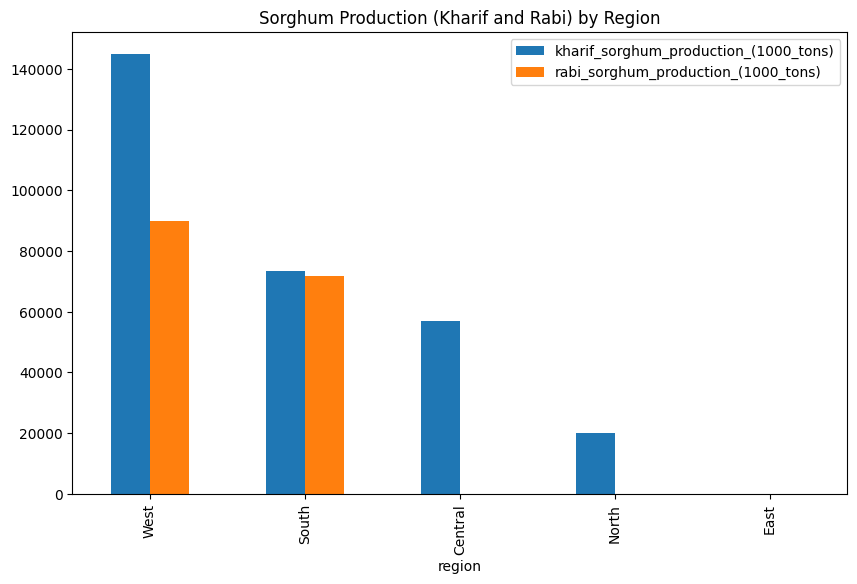

In [73]:
sorghum_region.set_index('region').plot(kind='bar', figsize=(10,6))
plt.title("Sorghum Production (Kharif and Rabi) by Region")
plt.show()

Sorghum production is highest in the West and Central regions, with Kharif season contributing the most production. Rabi sorghum production is comparatively lower due to irrigation dependency, while East and North regions show minimal production as they focus more on rice and wheat cultivation.insight:

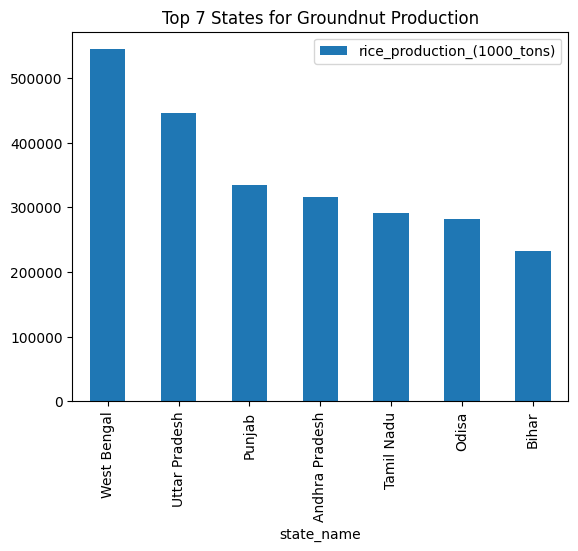

In [79]:
#Top 7 States for Groundnut Production
top_7_state_for_groundnut_production=cleaned_df.groupby('state_name')['groundnut_production_(1000_tons)'].sum().sort_values(ascending=False).reset_index().head(7)
top_7_rice_production_state.set_index('state_name').plot(kind='bar')
plt.title("Top 7 States for Groundnut Production")
plt.show()


In [110]:

cleaned_df['soyabean_area_(1000_ha)']=cleaned_df['soyabean_area_(1000_ha)'].replace(0,np.nan)

In [113]:

#Soybean Production by Top 5 States and Yield Efficiency
cleaned_df['soybean_yield'] = (
    cleaned_df['soyabean_production_(1000_tons)'] /
    cleaned_df['soyabean_area_(1000_ha)'])


In [121]:
soyabean_production_by_top_5_states_and_yield_efficiency=cleaned_df.groupby('state_name')[
    ['soyabean_production_(1000_tons)', 'soybean_yield']
].sum().reset_index().sort_values(by='soyabean_production_(1000_tons)',ascending=False).head(5)

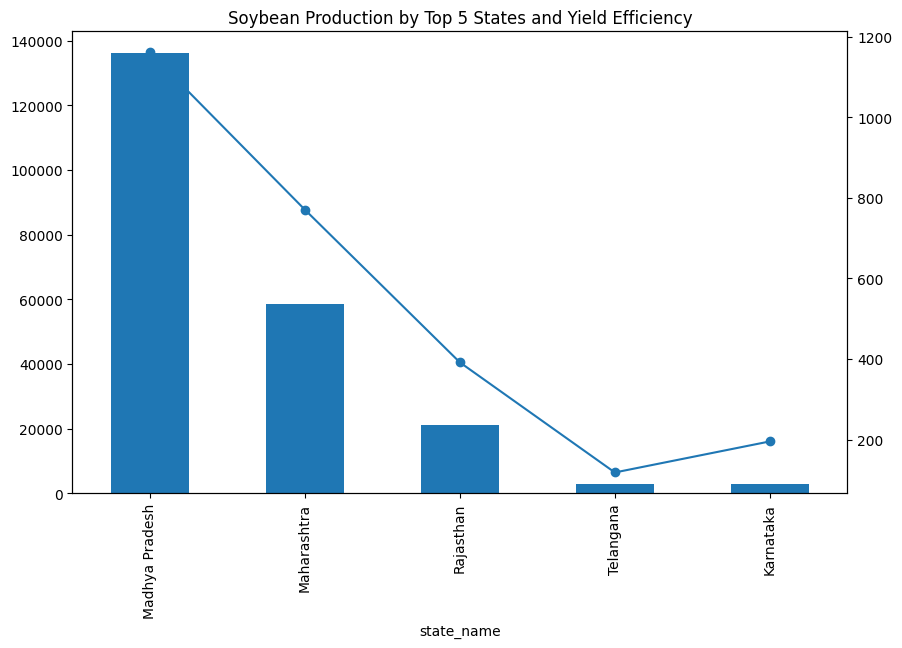

In [120]:
df_plot = soyabean_production_by_top_5_states_and_yield_efficiency

fig, ax1 = plt.subplots(figsize=(10,6))

df_plot.set_index("state_name")[
    'soyabean_production_(1000_tons)'
].plot(kind='bar', ax=ax1)

ax2 = ax1.twinx()

df_plot.set_index("state_name")[
    'soybean_yield'
].plot(ax=ax2, marker='o')

plt.title("Soybean Production by Top 5 States and Yield Efficiency")

plt.xticks(rotation=45)
plt.show()

In [123]:
cleaned_df.columns

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_(1000_ha)', 'rice_production_(1000_tons)',
       'rice_yield_(kg_per_ha)', 'wheat_area_(1000_ha)',
       'wheat_production_(1000_tons)', 'wheat_yield_(kg_per_ha)',
       'kharif_sorghum_area_(1000_ha)',
       'kharif_sorghum_production_(1000_tons)',
       'kharif_sorghum_yield_(kg_per_ha)', 'rabi_sorghum_area_(1000_ha)',
       'rabi_sorghum_production_(1000_tons)', 'rabi_sorghum_yield_(kg_per_ha)',
       'sorghum_area_(1000_ha)', 'sorghum_production_(1000_tons)',
       'sorghum_yield_(kg_per_ha)', 'pearl_millet_area_(1000_ha)',
       'pearl_millet_production_(1000_tons)', 'pearl_millet_yield_(kg_per_ha)',
       'maize_area_(1000_ha)', 'maize_production_(1000_tons)',
       'maize_yield_(kg_per_ha)', 'finger_millet_area_(1000_ha)',
       'finger_millet_production_(1000_tons)',
       'finger_millet_yield_(kg_per_ha)', 'barley_area_(1000_ha)',
       'barley_production_(1000_tons)', 'barley_

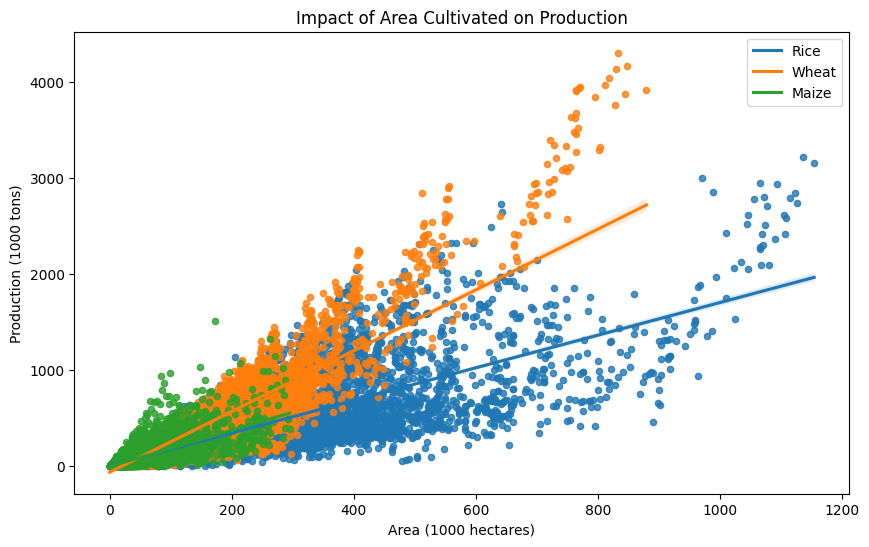

In [128]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=cleaned_df,
    x='rice_area_(1000_ha)',
    y='rice_production_(1000_tons)',
    scatter_kws={'s':20},
    line_kws={'label':'Rice'}
)

sns.regplot(
    data=cleaned_df,
    x='wheat_area_(1000_ha)',
    y='wheat_production_(1000_tons)',
    scatter_kws={'s':20},
    line_kws={'label':'Wheat'}
)

sns.regplot(
    data=cleaned_df,
    x='maize_area_(1000_ha)',
    y='maize_production_(1000_tons)',
    scatter_kws={'s':20},
    line_kws={'label':'Maize'}
)

plt.legend()
plt.title("Impact of Area Cultivated on Production")
plt.xlabel("Area (1000 hectares)")
plt.ylabel("Production (1000 tons)")

plt.show()

Rice and wheat show a strong positive relationship between cultivated area and production, indicating that increased land leads to higher output. Maize shows moderate correlation, suggesting that production depends on both cultivated area and yield efficiency.


In [137]:
cleaned_df['wheat_area_(1000_ha)']=cleaned_df['wheat_area_(1000_ha)'].replace(0,np.nan)
cleaned_df['rice_area_(1000_ha)']=cleaned_df['rice_area_(1000_ha)'].replace(0,np.nan)


In [141]:
#Rice vs. Wheat Yield Across States
cleaned_df['rice_yield'] = (
    cleaned_df['rice_production_(1000_tons)'] /
    cleaned_df['rice_area_(1000_ha)'])
cleaned_df['wheat_yield'] = (
    cleaned_df['wheat_production_(1000_tons)'] /
    cleaned_df['wheat_area_(1000_ha)'])
rice_vs_wheat_yield_across_state=cleaned_df.groupby('state_name')[['rice_yield','wheat_yield']].sum().reset_index()


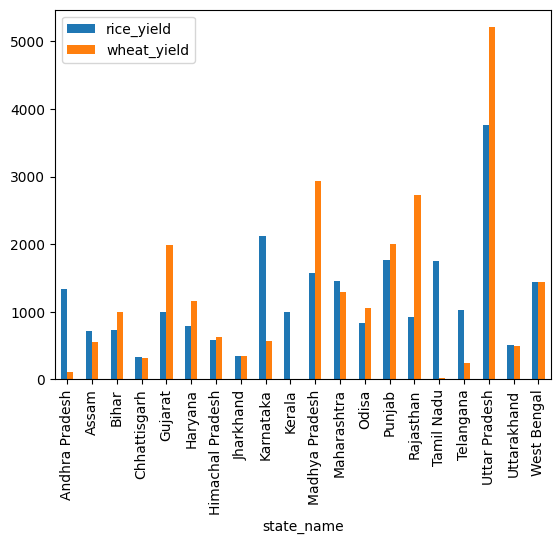

In [142]:
rice_vs_wheat_yield_across_state.set_index('state_name').plot(kind='bar')
plt.show()


Wheat yield is highest in Uttar Pradesh, Punjab, and Haryana, while rice yield is stronger in southern states like Karnataka and Tamil Nadu.
Northern states focus more on wheat, whereas southern states show higher rice productivity due to climatic and irrigation advantages.